# TDGL Local Simulation

Build device mesh via K8s workflow, generate timing schedule, run TDGL solver locally.
Je is the applied current between the two electrodes (source/drain).

In [ ]:
import os
import json
import uuid
import time
import tarfile
import io
import pickle

import httpx
import boto3
import numpy as np
import plotly.graph_objects as go
import tdgl
from hera.workflows import Workflow, WorkflowsService, Parameter
from hera.workflows.models import WorkflowTemplateRef as WTR
from tdgl_workflow.timing import build_timing_segmented

## Connections

In [9]:
gateway = 'http://localhost:30080'

argo_svc = WorkflowsService(
    host=gateway,
    verify_ssl=False,
    namespace='tdgl',
)

minio = boto3.client(
    's3',
    endpoint_url='http://localhost:30900',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin123',
    region_name='us-east-1',
)

print(f'Gateway: {gateway}')
print(f'MinIO Console: {gateway}/minio-ui/')

Gateway: http://localhost:30080
MinIO Console: http://localhost:30080/minio-ui/

## Device Parameters

In [10]:
params = {
    'film_width': 8.0,
    'film_height': 4.0,
    'elec_width': 0.5,
    'elec_height': 4.1,
    'elec_y_offset': 0.0,
    'probe_points': [
        [-3.0, 0.0],
        [ 3.0, 0.0],
    ],
    'max_edge_length': 0.25,
    'smooth': 100,
}

## Build Device (K8s)

In [11]:
run_id = str(uuid.uuid4())

wf = Workflow(
    generate_name='rect-device-',
    namespace='tdgl',
    workflow_template_ref=WTR(name='rectangle-device-builder'),
    arguments=[
        Parameter(name='run-id', value=run_id),
        Parameter(name='device-params-json', value=json.dumps(params)),
    ],
    workflows_service=argo_svc,
)

created = wf.create()
wf_name = created.metadata.name
print(f'Submitted: {wf_name}')
print(f'Run ID:    {run_id}')

Submitted: rect-device-95dw6
Run ID:    edcc9728-aac6-463e-8ab0-2e408897c4bc

In [ ]:
hint_map = {
    'Submitted': 'Scheduling...',
    'Pending': 'Pulling image...',
    'Running': 'Computing mesh...',
}

while True:
    url = f'{argo_svc.host}/api/v1/workflows/tdgl/{wf_name}'
    resp = httpx.get(url, verify=False, timeout=10)
    resp.raise_for_status()
    phase = (resp.json().get('status') or {}).get('phase', 'Unknown')

    if phase == 'Succeeded':
        print(f'{wf_name} succeeded.')
        break
    elif phase in {'Failed', 'Error'}:
        raise RuntimeError(f'{wf_name} {phase}')
    else:
        hint = hint_map.get(phase, 'Processing...')
        print(f'{wf_name} [{phase}] {hint}')
        time.sleep(3)

# Load pickled tdgl.Device from K8s artifact
device_key = f'{run_id}/device.pkl'
resp = minio.get_object(Bucket='argo-artifacts', Key=device_key)
raw = resp['Body'].read()

with tarfile.open(fileobj=io.BytesIO(raw), mode='r:gz') as tar:
    for member in tar.getmembers():
        f = tar.extractfile(member)
        if f:
            device = pickle.load(f)
            break

points = np.asarray(device.points)
triangles = np.asarray(device.triangles)

probe_indices = []
for px, py in params['probe_points']:
    dists = np.sqrt((points[:, 0] - px) ** 2 + (points[:, 1] - py) ** 2)
    probe_indices.append(int(np.argmin(dists)))

print(f'Device: {len(points)} sites, {len(triangles)} elements')
print(f'Probes: {probe_indices}')

In [ ]:
# Plot mesh
mx, my = [], []
for tri in triangles:
    for j in range(3):
        p0, p1 = points[tri[j]], points[tri[(j + 1) % 3]]
        mx += [p0[0], p1[0], None]
        my += [p0[1], p1[1], None]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=mx, y=my, mode='lines',
    line=dict(width=0.3, color='#94a3b8'),
    hoverinfo='skip', showlegend=False,
))

ec = {
    'source': ('#2563eb', 'rgba(37,99,235,0.35)'),
    'drain': ('#dc2626', 'rgba(220,38,38,0.35)'),
}
for t in device.terminal_info():
    idx = t.site_indices
    x0, x1 = points[idx, 0].min(), points[idx, 0].max()
    y0, y1 = points[idx, 1].min(), points[idx, 1].max()
    pad = 0.15
    lc, fc = ec.get(t.name, ('#888', 'rgba(136,136,136,0.35)'))
    fig.add_trace(go.Scatter(
        x=[x0 - pad, x1 + pad, x1 + pad, x0 - pad, x0 - pad],
        y=[y0 - pad, y0 - pad, y1 + pad, y1 + pad, y0 - pad],
        mode='lines', line=dict(width=1.5, color=lc), name=t.name,
        fill='toself', fillcolor=fc,
    ))

fig.add_trace(go.Scatter(
    x=points[probe_indices, 0], y=points[probe_indices, 1],
    mode='markers+text',
    marker=dict(size=8, symbol='x', color='#16a34a', line_width=2),
    text=[f'P{i+1}' for i in range(len(probe_indices))],
    textposition='top center', name='probes',
))

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
m = 0.3
fig.update_layout(
    title=f'Device ({len(points)} sites, {len(triangles)} elements)',
    xaxis=dict(range=[xmin - m, xmax + m], showline=True, linewidth=1,
               linecolor='black', mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[ymin - m, ymax + m],
               showline=True, linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5),
    margin=dict(l=40, r=10, t=35, b=50),
    height=280, width=700, plot_bgcolor='white',
)
fig.show()

## Timing Parameters

In [14]:
# Base timing parameters
je_initial = 0.0
je_final = 1.0
je_step = 0.1
ramp_time = 5.0
stable_time = 10.0
save_time = 5.0

segments = [
    {'je_initial': je_initial, 'je_final': je_final, 'je_step': je_step},
    {'je_initial': je_final, 'je_final': je_initial, 'je_step': -je_step},
]

In [15]:
result = build_timing_segmented(
    segments=segments,
    ramp_time=ramp_time,
    stable_time=stable_time,
    save_time=save_time,
)

steps = result['steps']
eq = steps[0]
print(f"Total steps: {result['n_steps']} (1 eq + {result['n_steps'] - 1} ramp)")
print(f"Solve time:  {result['solve_time']:.1f}s")
print()
print(f"  eq:  hold je={eq['je_start']:.2f}  t=0.0..{eq['stable_end']:.1f}s")
for i, s in enumerate(steps[1:], 1):
    print(f"  {i:2d}: je {s['je_start']:.2f} -> {s['je_end']:.2f}  "
          f"t={s['ramp_start']:.1f}..{s['stable_end']:.1f}s")

Total steps: 21 (1 eq + 20 ramp)
Solve time:  310.0s

  eq:  hold je=0.00  t=0.0..10.0s
   1: je 0.00 -> 0.10  t=10.0..25.0s
   2: je 0.10 -> 0.20  t=25.0..40.0s
   3: je 0.20 -> 0.30  t=40.0..55.0s
   4: je 0.30 -> 0.40  t=55.0..70.0s
   5: je 0.40 -> 0.50  t=70.0..85.0s
   6: je 0.50 -> 0.60  t=85.0..100.0s
   7: je 0.60 -> 0.70  t=100.0..115.0s
   8: je 0.70 -> 0.80  t=115.0..130.0s
   9: je 0.80 -> 0.90  t=130.0..145.0s
  10: je 0.90 -> 1.00  t=145.0..160.0s
  11: je 1.00 -> 0.90  t=160.0..175.0s
  12: je 0.90 -> 0.80  t=175.0..190.0s
  13: je 0.80 -> 0.70  t=190.0..205.0s
  14: je 0.70 -> 0.60  t=205.0..220.0s
  15: je 0.60 -> 0.50  t=220.0..235.0s
  16: je 0.50 -> 0.40  t=235.0..250.0s
  17: je 0.40 -> 0.30  t=250.0..265.0s
  18: je 0.30 -> 0.20  t=265.0..280.0s
  19: je 0.20 -> 0.10  t=280.0..295.0s
  20: je 0.10 -> 0.00  t=295.0..310.0s

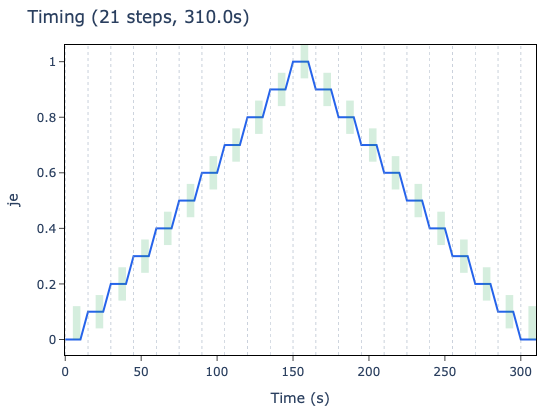

In [16]:
# Plot timing schedule
times = []
je_vals = []
for s in steps:
    times += [s['ramp_start'], s['ramp_end'], s['stable_end']]
    je_vals += [s['je_start'], s['je_end'], s['je_end']]

je_max = max(s['je_end'] for s in steps) or 1.0
band = je_max * 0.06

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=times, y=je_vals, mode='lines',
    line=dict(width=2, color='#2563eb'),
    name='Applied je',
))

for s in steps:
    y_center = s['je_end'] if s['je_end'] != 0 else band
    fig.add_shape(
        type='rect',
        x0=s['save_start'], x1=s['save_end'],
        y0=y_center - band, y1=y_center + band,
        fillcolor='rgba(22,163,74,0.18)', line_width=0,
    )

for s in steps:
    fig.add_vline(x=s['ramp_end'], line_width=0.5,
                  line_dash='dot', line_color='#94a3b8')

fig.update_layout(
    title=f"Timing ({len(steps)} steps, {result['solve_time']:.1f}s)",
    xaxis_title='Time (s)',
    yaxis_title='je',
    legend=dict(orientation='h', yanchor='bottom', y=1.02,
                xanchor='right', x=1),
    margin=dict(l=60, r=20, t=45, b=50),
    height=400, width=800, plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
)
fig.show()

## Run Simulation

In [17]:
# Solver parameters
dt_init = 1e-6
dt_max = 0.1
adaptive = True
save_every = 100
output_path = 'sim_output.h5'

In [ ]:
# Build terminal currents callable from timing steps
def get_terminal_currents(t):
    """Return {terminal_name: current} at time t."""
    for step in steps:
        if t < step['ramp_start']:
            continue
        ramp_duration = step['ramp_end'] - step['ramp_start']
        if ramp_duration > 0 and t <= step['ramp_end']:
            frac = (t - step['ramp_start']) / ramp_duration
            je = step['je_start'] + frac * (step['je_end'] - step['je_start'])
            return {'source': je, 'drain': -je}
        if t <= step['stable_end']:
            return {'source': step['je_end'], 'drain': -step['je_end']}
    return {'source': 0.0, 'drain': 0.0}


# Clean up previous output
if os.path.exists(output_path):
    os.remove(output_path)

options = tdgl.SolverOptions(
    solve_time=result['solve_time'],
    dt_init=dt_init,
    dt_max=dt_max,
    adaptive=adaptive,
    save_every=save_every,
    output_file=output_path,
)

solution = tdgl.solve(
    device,
    options,
    terminal_currents=get_terminal_currents,
)

print(f'Simulation complete. Saved {len(solution.times)} frames to {output_path}')

## Results

In [ ]:
# Extract I-V data: average voltage in each save window
sol_times = np.asarray(solution.times, dtype=np.float64)

iv_je = []
iv_voltage = []

for step in steps:
    mask = (sol_times >= step['save_start']) & (sol_times <= step['save_end'])
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue
    voltages = []
    for idx in indices:
        solution.load_tdgl_data(int(idx))
        mu = solution.tdgl_data.mu
        v = float(mu[probe_indices[1]] - mu[probe_indices[0]])
        voltages.append(v)
    iv_je.append(step['je_end'])
    iv_voltage.append(float(np.mean(voltages)))

print(f'Extracted {len(iv_je)} I-V points')
for je, v in zip(iv_je, iv_voltage):
    print(f'  je={je:6.2f}  V={v:+.6f}')

In [ ]:
# Plot I-V curve
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=iv_je, y=iv_voltage, mode='lines+markers',
    line=dict(width=2, color='#2563eb'),
    marker=dict(size=6),
    name='I-V',
))
fig.update_layout(
    title='I-V Curve',
    xaxis_title='je (applied current)',
    yaxis_title='Voltage (probe difference)',
    margin=dict(l=60, r=20, t=45, b=50),
    height=450, width=600, plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
)
fig.show()

In [ ]:
# Plot |psi| at the last saved frame
last_idx = len(sol_times) - 1
solution.load_tdgl_data(last_idx)
psi = solution.tdgl_data.psi
psi_abs = np.abs(psi)

fig = go.Figure(go.Scatter(
    x=points[:, 0], y=points[:, 1],
    mode='markers',
    marker=dict(
        size=3,
        color=psi_abs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='|\u03C8|'),
    ),
    text=[f'|\u03C8|={v:.3f}' for v in psi_abs],
    hovertemplate='%{text}<extra></extra>',
))

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
m = 0.3
fig.update_layout(
    title=f'|\u03C8| at t={sol_times[last_idx]:.1f}s',
    xaxis=dict(range=[xmin - m, xmax + m], showline=True, linewidth=1,
               linecolor='black', mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[ymin - m, ymax + m],
               showline=True, linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    margin=dict(l=40, r=10, t=35, b=50),
    height=400, width=700, plot_bgcolor='white',
)
fig.show()

## MinIO Artifact Management

In [ ]:
# Delete current run's artifacts
for k in [device_key, device_key.replace('device.pkl', 'mesh_result.json')]:
    try:
        minio.delete_object(Bucket='argo-artifacts', Key=k)
        print(f'Deleted {k}')
    except Exception:
        pass

In [ ]:
# List all artifacts
resp = minio.list_objects_v2(Bucket='argo-artifacts')
items = resp.get('Contents', [])

if not items:
    print('No artifacts in bucket.')
else:
    print(f'Found {len(items)} artifact(s):\n')
    for obj in items:
        print(f'  {obj["Key"]}  ({obj["Size"]/1024:.1f} KB)')

In [ ]:
# Delete a specific artifact — change the key below
delete_key = '<run-id>/device.pkl'

minio.delete_object(Bucket='argo-artifacts', Key=delete_key)
print(f'Deleted {delete_key}')

In [ ]:
# Delete ALL device artifacts
resp = minio.list_objects_v2(Bucket='argo-artifacts')
count = 0
for obj in resp.get('Contents', []):
    if 'device.pkl' in obj['Key'] or 'mesh_result.json' in obj['Key']:
        minio.delete_object(Bucket='argo-artifacts', Key=obj['Key'])
        print(f'Deleted {obj["Key"]}')
        count += 1
print(f'\nDone. Removed {count} artifact(s).')